In [64]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv('https://raw.githubusercontent.com/aishuej/dataset/main/car_data.csv')
print(df)



          Make       Model  Year                Engine Fuel Type  Engine HP  \
0          BMW  1 Series M  2011     premium unleaded (required)      335.0   
1          BMW    1 Series  2011     premium unleaded (required)      300.0   
2          BMW    1 Series  2011     premium unleaded (required)      300.0   
3          BMW    1 Series  2011     premium unleaded (required)      230.0   
4          BMW    1 Series  2011     premium unleaded (required)      230.0   
...        ...         ...   ...                             ...        ...   
11909    Acura         ZDX  2012     premium unleaded (required)      300.0   
11910    Acura         ZDX  2012     premium unleaded (required)      300.0   
11911    Acura         ZDX  2012     premium unleaded (required)      300.0   
11912    Acura         ZDX  2013  premium unleaded (recommended)      300.0   
11913  Lincoln      Zephyr  2006                regular unleaded      221.0   

       Engine Cylinders Transmission Type      Driv

In [25]:
df.dtypes

Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Market Category       object
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

In [26]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [65]:
df.duplicated().sum()

np.int64(715)

In [62]:
df=df.drop_duplicates(inplace = True)

In [66]:
df.drop('Market Category',axis='columns',inplace = True)
df.dropna(inplace=True)
df




,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,4dr Hatchback,23,16,204,50920


<Axes: >

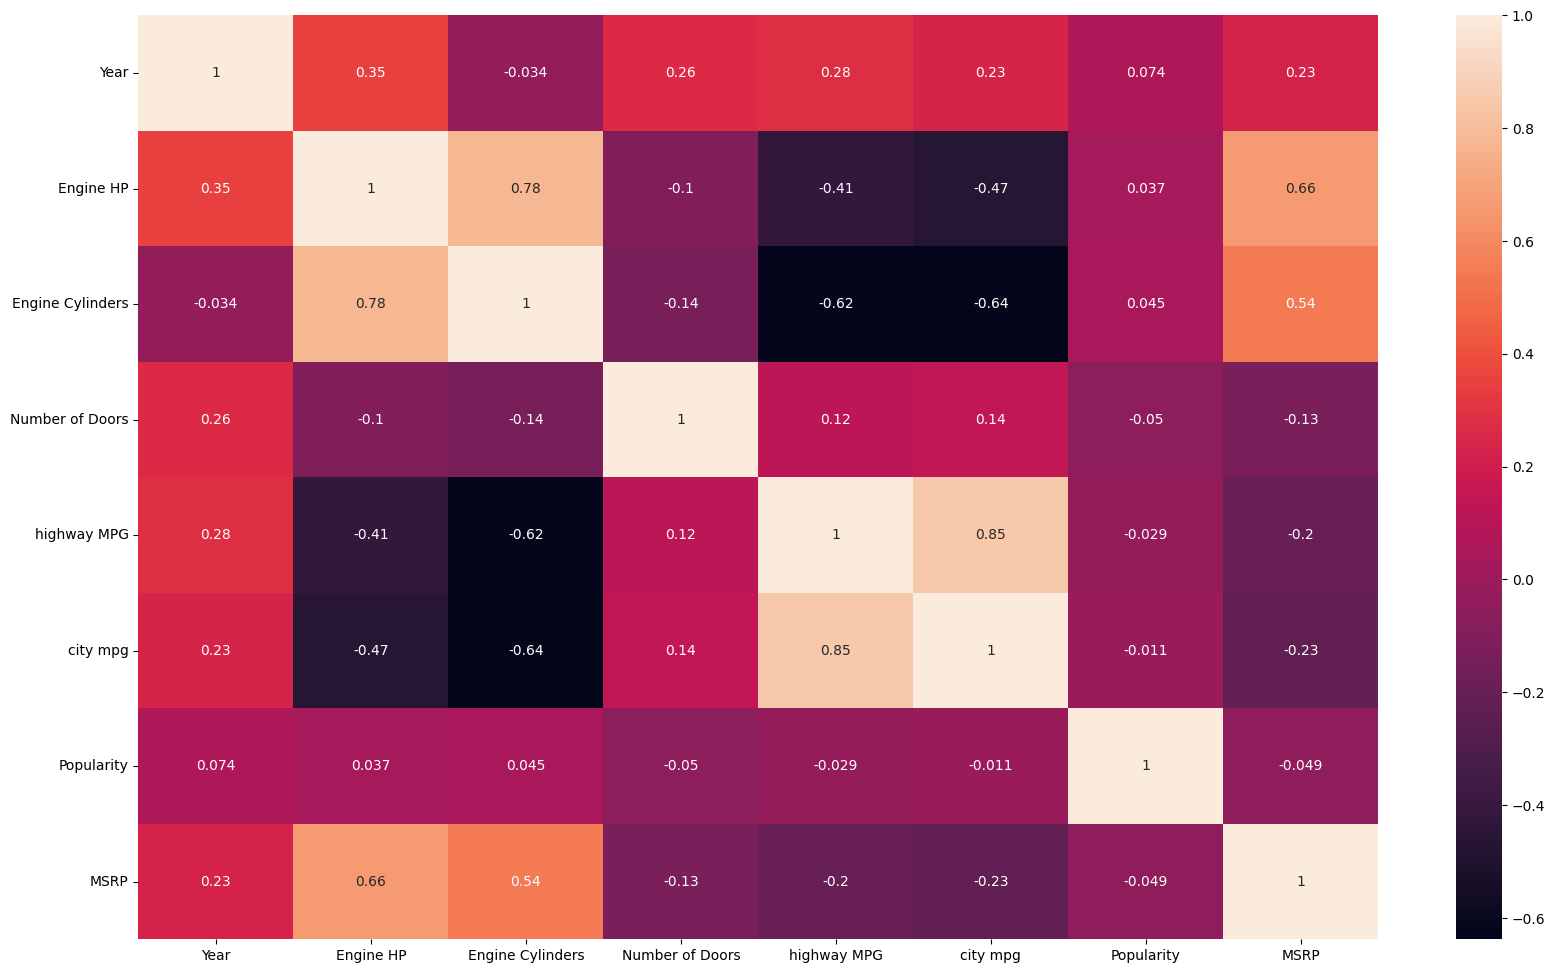

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,12))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)


<Axes: xlabel='MSRP'>

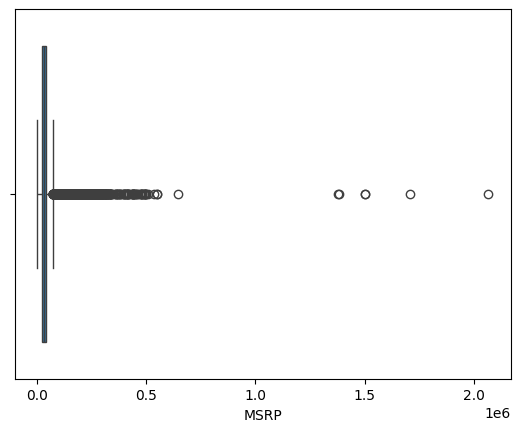

In [68]:
import seaborn as sns
sns.boxplot(x='MSRP',data =df)

In [47]:
q1= df.MSRP.quantile(.25)
q3=df.MSRP.quantile(.75)
q1,q3

(np.float64(21000.0), np.float64(42231.25))

In [75]:
IQR = q3-q1
IQR

np.float64(21231.25)

In [76]:
ll= q1-1.5*IQR
ul = q3+1.5*IQR
ll,ul

(np.float64(-10846.875), np.float64(74078.125))

In [77]:
# to find the ouliers
a=(df.MSRP<ll)|(df.MSRP>ul)
a

0        False
1        False
2        False
3        False
4        False
         ...  
11909    False
11910    False
11911    False
11912    False
11913    False
Name: MSRP, Length: 11812, dtype: bool

In [78]:
# to remove outliers
b=df[~((df.MSRP<ll)|(df.MSRP>ul))]
b

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,4,1,2011,7,335.0,6.0,3,3,2.0,0,8,26,19,3916,46135
1,4,0,2011,7,300.0,6.0,3,3,2.0,0,6,28,19,3916,40650
2,4,0,2011,7,300.0,6.0,3,3,2.0,0,8,28,20,3916,36350
3,4,0,2011,7,230.0,6.0,3,3,2.0,0,8,28,18,3916,29450
4,4,0,2011,7,230.0,6.0,3,3,2.0,0,6,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,0,892,2012,7,300.0,6.0,1,0,4.0,2,2,23,16,204,46120
11910,0,892,2012,7,300.0,6.0,1,0,4.0,2,2,23,16,204,56670
11911,0,892,2012,7,300.0,6.0,1,0,4.0,2,2,23,16,204,50620
11912,0,892,2013,6,300.0,6.0,1,0,4.0,2,2,23,16,204,50920


In [69]:
from sklearn.preprocessing import StandardScaler ,LabelEncoder 
for i in df.select_dtypes(include=['object']).columns:
    print(i)
    l=LabelEncoder()                                           # to convert categorial data to numerical data(labelEncoder())
    df[i]=l.fit_transform(df[i])
df                 # fit_transform (find unique value and transform them into numbers)

Make
Model
Engine Fuel Type
Transmission Type
Driven_Wheels
Vehicle Size
Vehicle Style


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,4,1,2011,7,335.0,6.0,3,3,2.0,0,8,26,19,3916,46135
1,4,0,2011,7,300.0,6.0,3,3,2.0,0,6,28,19,3916,40650
2,4,0,2011,7,300.0,6.0,3,3,2.0,0,8,28,20,3916,36350
3,4,0,2011,7,230.0,6.0,3,3,2.0,0,8,28,18,3916,29450
4,4,0,2011,7,230.0,6.0,3,3,2.0,0,6,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,0,892,2012,7,300.0,6.0,1,0,4.0,2,2,23,16,204,46120
11910,0,892,2012,7,300.0,6.0,1,0,4.0,2,2,23,16,204,56670
11911,0,892,2012,7,300.0,6.0,1,0,4.0,2,2,23,16,204,50620
11912,0,892,2013,6,300.0,6.0,1,0,4.0,2,2,23,16,204,50920


In [70]:
x = df.drop('MSRP',axis = 1)# independent columns
x
y = df['MSRP'] # dependent column
scaler = StandardScaler()
x= scaler.fit_transform(x)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train ,y_test = train_test_split(x,y,train_size=0.8,random_state=42)


In [71]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()  # calling the function
lin_reg.fit(x_train,y_train) # will find best m and c value

LinearRegression()

In [72]:
print(lin_reg.intercept_) #c
print(lin_reg.coef_) #m1,m2,m3,m4,m5

40991.70780003621
[ 1588.31247441 -1735.79367755 -1054.16662279  1984.46492215
 36441.78715873 15131.68789117 -4128.23211376 -3562.42416184
 -4239.39673004 -6972.74626269   696.16369587  4997.116922
  7521.64229585 -4429.746155  ]


In [73]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,r2_score
y_pred = lin_reg.predict(x_test) # 20% of independent value
print(y_pred)# y_test actual y_pred-predicted value
#calculate mean squared error
mse = mean_squared_error(y_test , y_pred)
rmse = np.sqrt(mse)
mae= mean_absolute_error(y_test,y_pred)
print('mean squared error:',mse)
print('root mean squared error:',rmse)
print('mean absolute error:',mae)

[ 8628.4865814  10704.66498683  8649.97612258 ... 53390.51934449
 32995.49687633  3740.94568225]
mean squared error: 914374093.2999763
root mean squared error: 30238.619236003095
mean absolute error: 20174.371089806627


In [79]:
#calculate
r2=r2_score(y_test,y_pred)
r2

0.5887322140247842